# DATASCI 503, Group Work 8: Support Vector Machines

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams (assigned by the GSI) to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. During lab, feel free to flag down your GSI to ask questions at any point!

## Overview of SVMs

In this section, we will experiment with SVMs and how to optimize SVM parameters using cross validation.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC

We will again use our old friend: the iris dataset.

This is one of the earliest datasets used in the literature on classification methods and widely used in statistics and machine learning. The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are not linearly separable from each other.

In [9]:
# Loading a new sample of data for the next example
iris = load_iris()
X = iris.data
Y = iris.target

Instead of directly running SVC (Support Vector Classification) method, we define the parameter space and ask the model to find the optimal parameter in the defined space using cross validation.

In [10]:
# Defining the parameter space to do the search

param_grid = {
    "C": np.logspace(-3, 3, 25),  # from .001 to 1000
    "gamma": np.logspace(-3, 3, 25),
}

In [11]:
svc = SVC(kernel="rbf")
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring="accuracy")  # 1-misclassification rate
grid_search.fit(X, Y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 1.77827941e-03, 3.16227766e-03, 5.62341325e-03,
       1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
       1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
       1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
       1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.623413...
                         'gamma': array([1.00000000e-03, 1.77827941e-03, 3.16227766e-03, 5.62341325e-03,
       1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
       1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
       1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
       1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
       1.00000000e+02, 1.77827941e+02, 3.16227766e+02, 5.62341325e+02,
       1.00000000e+03])},
             scoring='accuracy')

By using the following code, we can see the parameters leading to best performance

In [12]:
print("Best parameters: {}".format(grid_search.best_params_))

Best parameters: {'C': np.float64(3.1622776601683795), 'gamma': np.float64(0.1)}


Note that there could be two different hyperparmeter choices that both lead to the highest cross-validated accuracy.  The hyperparamers listed above indicate one possible choice that leads to highest cross-validated accuracy.

For a more comprehensive look, we can inspect `grid_search.cv_results_`.  This contains a dictionary of all the evaluation metrics from the gridsearch, usually we use a pd dataframe to visualize it properly.

I find a good explanation different columns and their meanings [here](https://stackoverflow.com/questions/54608088/what-is-gridsearch-cv-results-could-any-explain-all-the-things-in-that-i-e-me).

In [13]:
results = pd.DataFrame(grid_search.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000908,0.000235,0.000674,0.000036,0.001,0.001000,"{'C': 0.001, 'gamma': 0.001}",0.866667,0.966667,0.833333,0.966667,0.933333,0.913333,0.05416,329
1,0.000899,0.000156,0.000761,0.000137,0.001,0.001778,"{'C': 0.001, 'gamma': 0.0017782794100389228}",0.866667,0.966667,0.833333,0.966667,0.933333,0.913333,0.05416,329
2,0.000891,0.000164,0.000827,0.000165,0.001,0.003162,"{'C': 0.001, 'gamma': 0.0031622776601683794}",0.866667,0.966667,0.833333,0.966667,0.933333,0.913333,0.05416,329
3,0.000681,0.000026,0.000571,0.000023,0.001,0.005623,"{'C': 0.001, 'gamma': 0.005623413251903491}",0.866667,0.966667,0.833333,0.966667,0.933333,0.913333,0.05416,329
4,0.000679,0.000079,0.000541,0.000031,0.001,0.010000,"{'C': 0.001, 'gamma': 0.01}",0.866667,0.966667,0.833333,0.966667,0.933333,0.913333,0.05416,329


For a variety of choices of gamma, let's look at how cross-validated performance varies with $C$.

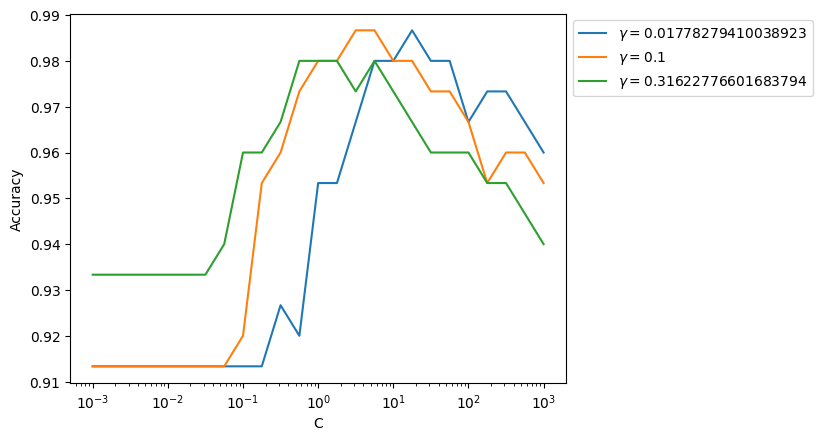

In [14]:
# choose a few values of gamma,
gamchoices = [param_grid["gamma"][5], param_grid["gamma"][8], param_grid["gamma"][10]]

for gam in gamchoices:
    subresults = results.loc[results["param_gamma"] == gam]
    plt.plot(subresults.param_C, subresults.mean_test_score, label=f"$\\gamma={gam}$")

plt.ylabel("Accuracy")

plt.xlabel("C")
plt.legend(bbox_to_anchor=[1, 1])
plt.gca().set_xscale("log")

Note that $\gamma=0.017$ and $\gamma=0.1$ both achieved the maximum cross-validated accuracy (98.67%).

This lab is adapted from [this github file](https://github.com/jpcolino/IPython_notebooks/blob/master/Cross-Validation%20in%20SVM.ipynb).

## Problems

---

**Problem 1:** Generate Synthetic Data

Using `make_blobs` generate an approximately linearly separable dataset. You will need to have 100 total samples and 2 binary classes and 2 features, the centers will need to be within $(-4,4) \times (-4, 4)\subset \mathbb{R}^2$. Use a cluster standard deviation of 1.5 and random state 503.

Store the features in `X_blobs` and labels in `y_blobs`.

In [82]:
?make_blobs

Signature:
make_blobs(
    n_samples=100,
    n_features=2,
    *,
    centers=None,
    cluster_std=1.0,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=None,
    return_centers=False,
)
Docstring:
Generate isotropic Gaussian blobs for clustering.

Read more in the :ref:`User Guide <sample_generators>`.

Parameters
----------
n_samples : int or array-like, default=100
    If int, it is the total number of points equally divided among
    clusters.
    If array-like, each element of the sequence indicates
    the number of samples per cluster.

    .. versionchanged:: v0.20
        one can now pass an array-like to the ``n_samples`` parameter

n_features : int, default=2
    The number of features for each sample.

centers : int or array-like of shape (n_centers, n_features), default=None
    The number of centers to generate, or the fixed center locations.
    If n_samples is an int and centers is None, 3 centers are generated.
    If n_samples is array-like, centers 

In [15]:
# generate a synthetic dataset for linear SVMs using make_blobs
from sklearn.datasets import make_blobs

centers = np.array([[-4.0, -4.0],
                    [ 4.0,  4.0]])  # both within (-4,4) x (-4,4)

X_blobs, y_blobs = make_blobs(
    n_samples=100,
    n_features=2,
    centers=centers,
    cluster_std=1.5,
    random_state=503,
)
y_blobs = y_blobs.astype(int)

In [16]:
# Test assertions
assert X_blobs.shape == (100, 2), f"Expected shape (100, 2), got {X_blobs.shape}"
assert y_blobs.shape == (100,), f"Expected shape (100,), got {y_blobs.shape}"
assert set(y_blobs) == {0, 1}, f"Expected 2 classes (0 and 1), got {set(y_blobs)}"
print("All tests passed!")


All tests passed!


---

**Problem 2:** Visualize the Data

Visualize your dataset by scattering `X_blobs` features and coloring them according to `y_blobs` labels. The zero class should be orange and the positive class skyblue. Use black contours to the dots and a transparency of 0.75. Add axis labels.

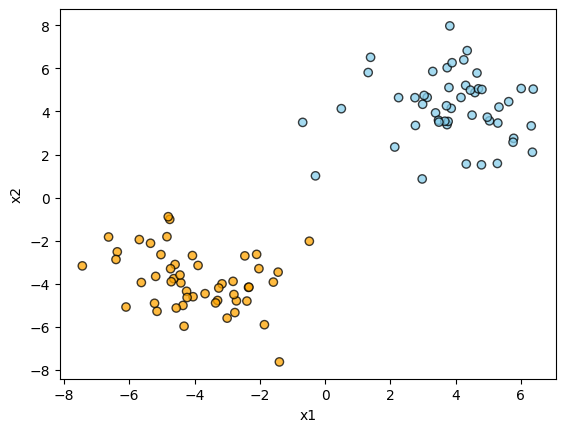

In [17]:
# visualize X_blobs, y_blobs, colors should be orange and skyblue

# map labels to requested colors
colors_blobs = np.where(y_blobs == 0, "orange", "skyblue")

plt.figure()
plt.scatter(
    X_blobs[:, 0], # x1
    X_blobs[:, 1], # x2
    c=colors_blobs,
    edgecolors="k",   # black contours
    alpha=0.75,
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [18]:
# Test assertions
assert "colors_blobs" in dir(), "colors_blobs variable should be defined"
assert len(colors_blobs) == len(y_blobs), "colors_blobs should have same length as y_blobs"
print("All tests passed!")


All tests passed!


---

**Problem 3:** Train a Linear SVM

Split the blobs data into training and test (80-20 split). Train a linear SVM and report the test accuracy. 

Store your model in `svm_blobs`. Store accuracy in `accuracy_blobs`. Use random state 503.

In [19]:
# split into train/test
X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs,
    y_blobs,
    test_size=0.2,
    random_state=503
)

# train linear SVM
svm_blobs = SVC(kernel="linear")
svm_blobs.fit(X_blobs_train, y_blobs_train)

# test accuracy
accuracy_blobs = svm_blobs.score(X_blobs_test, y_blobs_test)
print(f"Test accuracy: {accuracy_blobs:.3f}") # linearly separable data should give high accuracy 

Test accuracy: 1.000


In [20]:
# Test assertions
assert X_blobs_train.shape[0] == 80, f"Expected 80 training samples, got {X_blobs_train.shape[0]}"
assert X_blobs_test.shape[0] == 20, f"Expected 20 test samples, got {X_blobs_test.shape[0]}"
assert hasattr(svm_blobs, "coef_"), "SVM should be fitted and have coef_ attribute"
assert 0 <= accuracy_blobs <= 1, "Accuracy should be between 0 and 1"
print("All tests passed!")


All tests passed!


---

**Problem 4:** Plot Decision Boundary and Margins

Extract the weight vector and bias from `svm_blobs`. Then plot the decision boundary
$$
w_1 x_1 + w_2 x_2 + b = 0
$$
as a black dashed line. Also plot the margins
$$
w_1 x_1 + w_2 x_2 + b = \pm 1
$$
as black dashed lines with dots `-.`.

Highlight support vectors and store them in `support_vectors_blobs`.

In [21]:
svm_blobs.coef_
# svm_blobs.coef_.ravel().shape

array([[0.15429384, 0.64941595]])

In [22]:
# ?svm_blobs
svm_blobs.intercept_[0]

np.float64(0.3872075574918226)

In [91]:
svm_blobs.support_vectors_

array([[-4.75921567, -1.00614469],
       [-0.48210481, -2.02114453],
       [-0.29389822,  1.01383003]])

In [92]:
support_vectors_blobs

array([[-4.75921567, -1.00614469],
       [-0.48210481, -2.02114453],
       [-0.29389822,  1.01383003]])

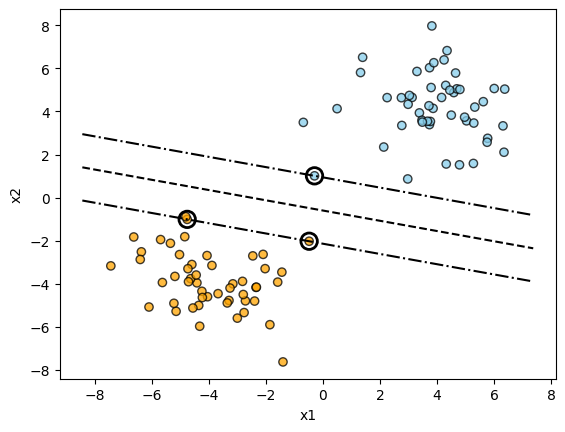

In [24]:
# Extract w, b
w_blobs = svm_blobs.coef_.ravel()
b_blobs = float(svm_blobs.intercept_[0])

# Support vectors (training points used by the SVM)
support_vectors_blobs = svm_blobs.support_vectors_

# Scatter all points
colors_blobs = np.where(y_blobs == 0, "orange", "skyblue")
plt.figure()
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=colors_blobs, edgecolors="k", alpha=0.75)

# Circle the support vectors
plt.scatter(
    support_vectors_blobs[:, 0],
    support_vectors_blobs[:, 1],
    s=140,
    facecolors="none",
    edgecolors="k",
    linewidths=2,
)

# Lines: w1*x1 + w2*x2 + b = 0, ±1  ->  x2 = -(w1*x1 + b - c)/w2
xs = np.linspace(X_blobs[:, 0].min() - 1, X_blobs[:, 0].max() + 1, 200)
y_dec = -(w_blobs[0] * xs + b_blobs) / w_blobs[1]
y_m1  = -(w_blobs[0] * xs + b_blobs - 1) / w_blobs[1]
y_p1  = -(w_blobs[0] * xs + b_blobs + 1) / w_blobs[1]

plt.plot(xs, y_dec, "k--")
plt.plot(xs, y_m1, "k-.")
plt.plot(xs, y_p1, "k-.")

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [25]:
# Test assertions
assert w_blobs.shape == (2,), f"Weight vector should have 2 components, got {w_blobs.shape}"
assert isinstance(b_blobs, float), "Bias should be a scalar"
print("All tests passed!")


All tests passed!


---

**Problem 5:** Count Observations Within Margins

Compute how many observations in `X_blobs` are within the margins of `svm_blobs`. Save in `obs_within_margins`.

In [95]:
# svm_blobs.decision_function?

In [27]:
# Compute how many observations are within the margins
# points between the two margin lines satisfy -1 <= w^T x + b <= 1
scores = svm_blobs.decision_function(X_blobs)
y_signed = np.where(y_blobs == 0, -1, 1)

tol = 1e-8
obs_within_margins = int(np.sum(y_signed * scores <= 1 + tol))

obs_within_margins

2

In [28]:
# Test assertions
assert isinstance(obs_within_margins, int | np.integer), "Should be an integer"
assert obs_within_margins >= 0, "Count should be non-negative"
assert obs_within_margins <= len(X_blobs), "Count should not exceed total observations"
print("All tests passed!")


All tests passed!


---

**Problem 6:** Generate Non-Linearly Separable Data

Use `make_circles` to generate a non-linearly separable dataset. Your sample should have 100 datapoints, noise level of 0.15, a scale factor of 0.25 and random state 503.

Store the features in `X_circles` and labels in `y_circles`.

In [29]:
from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(
    n_samples=100,
    noise=0.15,
    factor=0.25,
    random_state=503,
)

y_circles = y_circles.astype(int)

In [30]:
# Test assertions
assert X_circles.shape == (100, 2), f"Expected shape (100, 2), got {X_circles.shape}"
assert y_circles.shape == (100,), f"Expected shape (100,), got {y_circles.shape}"
assert set(y_circles) == {0, 1}, f"Expected 2 classes (0 and 1), got {set(y_circles)}"
print("All tests passed!")


All tests passed!


---

**Problem 7:** Linear SVM on Circles Data

Split the circles data with a 80-20 train test split. Train a linear SVM (store it as `svm_circles`). Plot the resulting linear boundary and margins. Scatter the points with orange for class 0 and skyblue for class 1. Then add a box to the bottom left of the plot with the test accuracy.

Use random state 503 and save in `test_accuracy_circles`.

In [ ]:
np.bincount(y_circles)

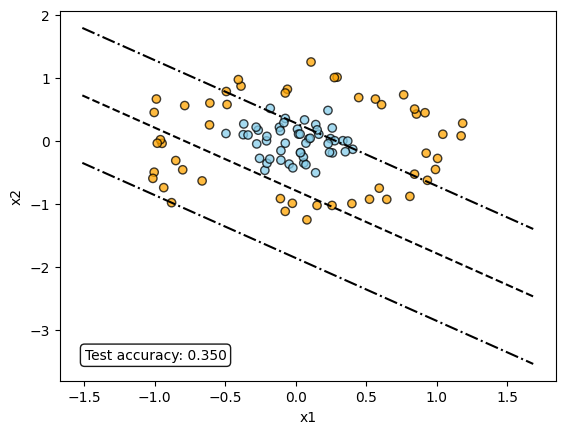

In [31]:
# split data and train linear SVM
# train/test split
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles,
    y_circles,
    test_size=0.2,
    random_state=503
)

# fit linear SVM
svm_circles = SVC(kernel="linear")
svm_circles.fit(X_circles_train, y_circles_train)

# test accuracy
test_accuracy_circles = svm_circles.score(X_circles_test, y_circles_test)

# plot data + linear boundary + margins
colors_circles = np.where(y_circles == 0, "orange", "skyblue")

w = svm_circles.coef_.ravel()
b = float(svm_circles.intercept_[0])

xs = np.linspace(X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5, 300)
y_dec = -(w[0] * xs + b) / w[1] # decision boundary: w1*x1 + w2*x2 + b = 0  ->  x2 = -(w1*x1 + b)/w2
y_m1  = -(w[0] * xs + b - 1) / w[1] # margin line 1: w1*x1 + w2*x2 + b = 1  ->  x2 = -(w1*x1 + b - 1)/w2
y_p1  = -(w[0] * xs + b + 1) / w[1] # margin line 2: w1*x1 + w2*x2 + b = -1  ->  x2 = -(w1*x1 + b + 1)/w2

fig, ax = plt.subplots()
ax.scatter(X_circles[:, 0], X_circles[:, 1], c=colors_circles, edgecolors="k", alpha=0.75)

ax.plot(xs, y_dec, "k--")
ax.plot(xs, y_m1, "k-.")
ax.plot(xs, y_p1, "k-.")

ax.set_xlabel("x1")
ax.set_ylabel("x2")

ax.text(
    0.05,
    0.05,
    f"Test accuracy: {test_accuracy_circles:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
)

plt.show()

In [32]:
# Test assertions
assert (
    X_circles_train.shape[0] == 80
), f"Expected 80 training samples, got {X_circles_train.shape[0]}"
assert hasattr(svm_circles, "coef_"), "SVM should be fitted"
assert 0 <= test_accuracy_circles <= 1, "Accuracy should be between 0 and 1"
print("All tests passed!")



All tests passed!


---

**Problem 8:** Kernel SVM and Quadratic Features

Fit a Kernel SVM with polynomial kernel of degree 2. Then fill in the quadratic features function. It should transform each row $(x_1, x_2)$ of our data matrix $X$ into
$$
\phi(x_1, x_2) = (1, \sqrt{2} x_1, \sqrt{2} x_2, x_1^2, \sqrt{2} x_1 x_2, x_2^2)$$
Then use this function to fit a linear svm on this feature space. Print both methods accuracies. They should match!

Use names `lin_feature_svm, poly_svm, poly_accuracy, lin_feature_accuracy`.


In [33]:
def quadratic_features(features: np.ndarray) -> np.ndarray:
    """
    Generate quadratic features.

    Transforms each row (x1, x2) into:
    (1, sqrt(2)*x1, sqrt(2)*x2, x1^2, sqrt(2)*x1*x2, x2^2)
    """
    features = np.asarray(features, dtype=float)
    x1 = features[:, 0]
    x2 = features[:, 1]
    r2 = np.sqrt(2.0)

    # Stack the features into the desired format
    return np.column_stack(
        [
            np.ones(features.shape[0]),
            r2 * x1,
            r2 * x2,
            x1**2,
            r2 * x1 * x2,
            x2**2,
        ]
    )

In [34]:
# Test assertions
test_input = np.array([[1.0, 2.0], [3.0, 4.0]])
test_output = quadratic_features(test_input)
assert test_output.shape == (2, 6), f"Expected shape (2, 6), got {test_output.shape}"
assert test_output[0, 0] == 1.0, "First column should be 1"
print("All tests passed!")


All tests passed!


In [36]:
# Fit kernel SVM and linear SVM on quadratic features

# Polynomial kernel corresponding to <phi(x), phi(z)> = (1 + x^T z)^2
C = 1.0
poly_svm = SVC(kernel="poly", degree=2, gamma=1.0, coef0=1.0, C=C)
poly_svm.fit(X_circles_train, y_circles_train)
poly_accuracy = poly_svm.score(X_circles_test, y_circles_test)

# Linear SVM in the explicit quadratic feature space
X_train_phi = quadratic_features(X_circles_train)
X_test_phi = quadratic_features(X_circles_test)

lin_feature_svm = SVC(kernel="linear", C=C)
lin_feature_svm.fit(X_train_phi, y_circles_train)
lin_feature_accuracy = lin_feature_svm.score(X_test_phi, y_circles_test)

print(f"Polynomial-kernel SVM accuracy: {poly_accuracy:.3f}")
print(f"Linear SVM on quadratic features accuracy: {lin_feature_accuracy:.3f}")

Polynomial-kernel SVM accuracy: 1.000
Linear SVM on quadratic features accuracy: 1.000


In [37]:
# Test assertions
assert hasattr(poly_svm, "support_vectors_"), "poly_svm should be fitted"
assert hasattr(lin_feature_svm, "coef_"), "lin_feature_svm should be fitted"
assert 0 <= poly_accuracy <= 1, "poly_accuracy should be between 0 and 1"
assert 0 <= lin_feature_accuracy <= 1, "lin_feature_accuracy should be between 0 and 1"
print("All tests passed!")


All tests passed!


---

**Problem 9:** Compare Decision Boundaries

Plot the decision boundary for both methods. Here is an outline:


1.   create a meshgrid
2.   evaluate $w^\top\phi(x) + b$ on the meshgrid using `svc.decision_function` for both methods. Note that you have to pass the grid through `quadratic_features` for the second method.
3.   scatter data points
4.   use `plt.contour` to get the decision boundary for the 2 methods.

Use names `Z_poly, Z_feature`.


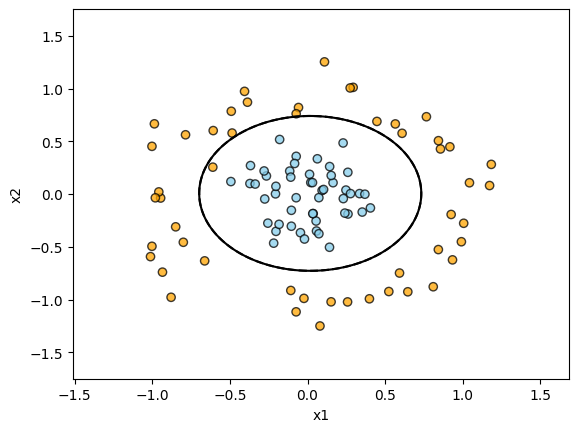

In [38]:
# Plot decision boundaries for both methods

# meshgrid over the circles data range
x_min, x_max = X_circles[:, 0].min() - 0.5, X_circles[:, 0].max() + 0.5
y_min, y_max = X_circles[:, 1].min() - 0.5, X_circles[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)

grid = np.c_[xx.ravel(), yy.ravel()]

# decision function values on the grid
Z_poly = poly_svm.decision_function(grid).reshape(xx.shape)

grid_phi = quadratic_features(grid)
Z_feature = lin_feature_svm.decision_function(grid_phi).reshape(xx.shape)

# scatter the data
colors_circles = np.where(y_circles == 0, "orange", "skyblue")
plt.figure()
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=colors_circles, edgecolors="k", alpha=0.75)

# decision boundaries (level set = 0)
plt.contour(xx, yy, Z_poly, levels=[0], colors="k", linestyles="--")
plt.contour(xx, yy, Z_feature, levels=[0], colors="k", linestyles="-")

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


In [39]:
# Test assertions
assert Z_poly.shape == xx.shape, "Z_poly should match meshgrid shape"
assert Z_feature.shape == xx.shape, "Z_feature should match meshgrid shape"
print("All tests passed!")



All tests passed!
